In [1]:
# imports
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [2]:
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [3]:
DATA_DIR = Path("/content/")

TRAIN_PATH = DATA_DIR / "wiki.train.raw"
VALID_PATH = DATA_DIR / "wiki.valid.raw"
TEST_PATH = DATA_DIR / "wiki.test.raw"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [4]:
def load_text_file(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        return f.read().splitlines()

In [5]:
train_data = load_text_file(TRAIN_PATH)
valid_data = load_text_file(VALID_PATH)
test_data = load_text_file(TEST_PATH)

In [6]:
train_data

[' ',
 ' = Valkyria Chronicles III = ',
 ' ',
 ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . ',
 " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more for



---

#  **Exploatory Data Analysis**

---



Basic Inspection

In [7]:
def dataset_statistics(lines, file_path):
    total_lines = len(lines)
    empty_lines = sum(line.strip() == "" for line in lines)
    non_empty_lines = total_lines - empty_lines
    total_characters = sum(len(line) for line in lines)
    total_words = sum(len(line.split()) for line in lines)
    file_size_mb = file_path.stat().st_size / (1024 * 1024)
    return {
        "File": file_path.name,
        "Total Lines": total_lines,
        "Empty Lines": empty_lines,
        "Non Empty Lines": non_empty_lines,
        "Characters": total_characters,
        "Words": total_words,
        "File Size (MB)": round(file_size_mb, 2)
    }

In [8]:
summary = pd.DataFrame([
    dataset_statistics(train_data, TRAIN_PATH),
    dataset_statistics(valid_data, VALID_PATH),
    dataset_statistics(test_data, TEST_PATH)
])

summary

,File,Total Lines,Empty Lines,Non Empty Lines,Characters,Words,File Size (MB)
0,wiki.train.raw,36718,12951,23767,10882174,2051910,10.43
1,wiki.valid.raw,3760,1299,2461,1140988,213886,1.09
2,wiki.test.raw,4358,1467,2891,1284198,241211,1.23


# Is the train split much larger?
Yes, the training split (wiki.train.raw) is significantly larger than both the validation and test splits. It has over 36,000 total lines, 2 million words, and 10 million characters, which is roughly 8-10 times larger than the validation and test sets.

# Are validation and test similar?
Yes, the validation (wiki.valid.raw) and test (wiki.test.raw) splits appear to be similar in size. The validation set has 3,760 total lines and 213,886 words, while the test set has 4,358 total lines and 241,211 words. They are of comparable magnitude.

#Are there many empty lines?
Yes, there are a notable number of empty lines across all splits. For instance, in the training set, approximately one-third of the lines (12,951 out of 36,718) are empty. Similar proportions are observed in the validation and test sets.

In [9]:
print("First 10 Training Samples\n")
for i, line in enumerate(train_data[:10]):
    print(f"{i+1}. {repr(line)}")

First 10 Training Samples

1. ' '
2. ' = Valkyria Chronicles III = '
3. ' '
4. ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . '
5. " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments ,

In [10]:

for i, line in enumerate(test_data[:10]):
    print(f"{i+1}. {repr(line)}")

1. ' '
2. ' = Robert Boulter = '
3. ' '
4. ' Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role on the television series The Bill in 2000 . This was followed by a starring role in the play Herons written by Simon Stephens , which was performed in 2001 at the Royal Court Theatre . He had a guest role in the television series Judge John Deed in 2002 . In 2004 Boulter landed a role as " Craig " in the episode " Teddy \'s Story " of the television series The Long Firm ; he starred alongside actors Mark Strong and Derek Jacobi . He was cast in the 2005 theatre productions of the Philip Ridley play Mercury Fur , which was performed at the Drum Theatre in Plymouth and the Menier Chocolate Factory in London . He was directed by John Tiffany and starred alongside Ben Whishaw , Shane Zaza , Harry Kent , Fraser Ayres , Sophie Stanton and Dominic Hall . '
5. ' In 2006 , Boulter starred alongside Whishaw in the play Citizenship written by Mark Ravenh

In [11]:

for i, line in enumerate(valid_data[:10]):
    print(f"{i+1}. {repr(line)}")

1. ' '
2. ' = Homarus gammarus = '
3. ' '
4. ' Homarus gammarus , known as the European lobster or common lobster , is a species of clawed lobster from the eastern Atlantic Ocean , Mediterranean Sea and parts of the Black Sea . It is closely related to the American lobster , H. americanus . It may grow to a length of 60 cm ( 24 in ) and a mass of 6 kilograms ( 13 lb ) , and bears a conspicuous pair of claws . In life , the lobsters are blue , only becoming " lobster red " on cooking . Mating occurs in the summer , producing eggs which are carried by the females for up to a year before hatching into planktonic larvae . Homarus gammarus is a highly esteemed food , and is widely caught using lobster pots , mostly around the British Isles . '
5. ' '
6. ' = = Description = = '
7. ' '
8. ' Homarus gammarus is a large crustacean , with a body length up to 60 centimetres ( 24 in ) and weighing up to 5 – 6 kilograms ( 11 – 13 lb ) , although the lobsters caught in lobster pots are usually 23 – 

In [12]:
print("Last 10 Samples\n")
for i, line in enumerate(train_data[-10:]):
    print(f"{i+1}. {repr(line)}")

Last 10 Samples

1. ' Western Australia banned the import of common starlings in 1895 . New flocks arriving from the east are routinely shot , while the less cautious juveniles are trapped and netted . New methods are being developed , such as tagging one bird and tracking it back to establish where other members of the flock roost . Another technique is to analyse the DNA of Australian common starling populations to track where the migration from eastern to western Australia is occurring so that better preventive strategies can be used . By 2009 , only 300 common starlings were left in Western Australia , and the state committed a further A $ 400 @,@ 000 in that year to continue the eradication programme . '
2. ' In the United States , common starlings are exempt from the Migratory Bird Treaty Act , which prohibits the taking or killing of migratory birds . No permit is required to remove nests and eggs or kill juveniles or adults . Research was undertaken in 1966 to identify a suitab

In [13]:
def random_samples(lines, n=10):
    samples = random.sample(lines, n)
    for idx, sample in enumerate(samples, 1):
        print(f"{idx}. {repr(sample)}\n")

In [14]:
random_samples(train_data)

1. ' Politically , Ireland is divided between the Republic of Ireland ( officially named Ireland ) , which covers five @-@ sixths of the island , and Northern Ireland , which is part of the United Kingdom , in the northeast of the island . In 2011 the population of Ireland was about 6 @.@ 4 million , ranking it the second @-@ most populous island in Europe after Great Britain . Just under 4 @.@ 6 million live in the Republic of Ireland and just over 1 @.@ 8 million live in Northern Ireland . '

2. " The Great Coastal hurricane of 1806 was first noted far east of the Lesser Antilles on 17 August . Weather historian David M. Ludlum followed the disturbance 's track to the Bahamas by 19 August ; intense winds persisted until 21 August , however , approximately 150 mi ( 240 km ) east of the Bahamian island of Eleuthera . Steering currents brought the storm northward , and it approached Charleston , South Carolina on 22 August , where a generally easterly flow preceded the storm indicated i

In [15]:
random_samples(test_data)

1. ' The IJN then decided to use the sisters and their escorts to bring a load of petrol , rubber , tin and other strategic minerals back to Japan after the American carriers departed the South China Sea ( Operation Kita ) . They loaded their cargoes beginning on 6 February at Singapore and departed four days later . Also carrying some 1 @,@ 150 oilfield workers , they were escorted by Ōyodo and three destroyers . Decrypted Japanese radio signals revealed the Japanese plan to the Allies , and 15 submarines were positioned along their anticipated route in an attempt to intercept and sink the ships . An additional 11 were moved into position while the group was en route , but only three were ultimately able to attack . None of them were successful before the Japanese reached Kure on 20 February . The Fourth Carrier Division was disbanded on 1 March and the sisters were reduced to 1st rank reserve ships . On 19 March Kure was attacked by aircraft from Task Force 58 and Hyūga was hit three

In [16]:
random_samples(valid_data)

1. " Beckham 's political career began in 1894 when he was elected without opposition to the Kentucky House of Representatives . He served four consecutive terms and was Speaker of the House in 1898 , his final year in the House . He also served as a delegate to every Democratic National Convention from 1900 to 1920 . "

2. " Finally , defense asked for adjournment as a key witness fell ill . The court decided to continue with the hearings the next day , after which the hearings would be adjourned until March 4 , 2013 , in order to hear the defense 's witness . Blythe committed to return when the trial resumed . "

3. ' Meanwhile , in 1274 , the former Dali Kingdom was officially reorganized as the Province of Yunnan , with Sayyid Ajjal Shams al @-@ Din Omar as governor . In May 1275 , the governor sent a report to the emperor stating that the embassy had not returned ; that the Burmese evidently had no intention of submitting ; and that war was the only way forward . '

4. ' = = Relea

In [17]:
def line_uniqueness(lines):
    total = len(lines)
    unique = len(set(lines))
    duplicates = total - unique

    print(f"Total Lines      : {total:,}")
    print(f"Unique Lines     : {unique:,}")
    print(f"Duplicate Lines  : {duplicates:,}")
    print(f"Duplicate Ratio  : {duplicates/total:.2%}")

In [18]:
line_uniqueness(train_data)

Total Lines      : 36,718
Unique Lines     : 21,714
Duplicate Lines  : 15,004
Duplicate Ratio  : 40.86%


In [19]:
def empty_lines_count(lines):
    empty = sum(line == '' for line in lines)
    whitespace = sum(
        line != "" and line.strip() == ""
        for line in lines
    )
    print(f"Empty Lines       : {empty:,}")
    print(f"Whitespace Lines  : {whitespace:,}")

In [20]:
empty_lines_count(train_data)

Empty Lines       : 0
Whitespace Lines  : 12,951


In [21]:
empty_lines_count(test_data)

Empty Lines       : 0
Whitespace Lines  : 1,467


In [22]:
empty_lines_count(valid_data)

Empty Lines       : 0
Whitespace Lines  : 1,299


In [23]:
for line in train_data:
    if line.strip() == "":
        print(repr(line))
        break

' '


In [24]:
def inspect_whitespace_lines(lines, n=20):
    whitespace_lines = [line for line in lines if line.strip() == ""]
    print(f"Total Whitespace Lines: {len(whitespace_lines):,}\n")
    print(f"Showing first {min(n, len(whitespace_lines))} whitespace lines:\n")
    for idx, line in enumerate(whitespace_lines[:n], 1):
        print(f"{idx}. {repr(line)}")

In [25]:
inspect_whitespace_lines(train_data)

Total Whitespace Lines: 12,951

Showing first 20 whitespace lines:

1. ' '
2. ' '
3. ' '
4. ' '
5. ' '
6. ' '
7. ' '
8. ' '
9. ' '
10. ' '
11. ' '
12. ' '
13. ' '
14. ' '
15. ' '
16. ' '
17. ' '
18. ' '
19. ' '
20. ' '


In [26]:
from collections import Counter

def whitespace_patterns(lines):
    whitespace = [repr(line) for line in lines if line.strip() == ""]
    counter = Counter(whitespace)

    df = pd.DataFrame(
        counter.items(),
        columns=["Whitespace Pattern", "Count"]
    )
    return df.sort_values("Count", ascending=False)

In [27]:
whitespace_patterns(train_data)

,Whitespace Pattern,Count
0,' ',12951


In [28]:
from collections import Counter

def duplicate_line_analysis(lines, top_n=30):
    counter = Counter(lines)
    duplicates = {
        line: count
        for line, count in counter.items()
        if count > 1
    }
    duplicates = sorted(
        duplicates.items(),
        key=lambda x: x[1],
        reverse=True
    )
    df = pd.DataFrame(
        duplicates,
        columns=["Line", "Frequency"]
    )

    return df.head(top_n)

In [29]:
duplicate_line_analysis(train_data)

,Line,Frequency
0,,12951
1,= = History = =,129
2,= = Reception = =,105
3,= = Background = =,82
4,= = Production = =,61
5,= = Plot = =,60
6,= = Legacy = =,39
7,= = Description = =,39
8,= = Route description = =,29
9,= = Development = =,28


In [46]:
import re

def heading_statistics(lines):
    patterns = {
        "Level 1 (= Title =)":
            r"^= [^=].* =$",

        "Level 2 (= = Heading = =)":
            r"^= = .* = =$",

        "Level 3 (= = = Heading = = =)":
            r"^= = = .* = = =$"
    }
    results = {}
    for name, pattern in patterns.items():
        count = sum(
            bool(re.match(pattern, line.strip()))
            for line in lines
        )
        results[name] = count
    return pd.DataFrame(
        results.items(),
        columns=["Heading Type", "Count"]
    )

In [47]:
heading_statistics(train_data)

,Heading Type,Count
0,Level 1 (= Title =),629
1,Level 2 (= = Heading = =),5582
2,Level 3 (= = = Heading = = =),2660


In [32]:
def heading_examples(lines, n=20):
    headings = [
        line for line in lines
        if line.strip().startswith("=")
    ]
    for idx, heading in enumerate(headings[:n], 1):
        print(f"{idx}. {heading}")

In [33]:
heading_examples(train_data)

1.  = Valkyria Chronicles III = 
2.  = = Gameplay = = 
3.  = = Plot = = 
4.  = = Development = = 
5.  = = = Music = = = 
6.  = = = Release = = = 
7.  = = Reception = = 
8.  = = Legacy = = 
9.  = = = Adaptations = = = 
10.  = Tower Building of the Little Rock Arsenal = 
11.  = = Construction = = 
12.  = = Civil War = = 
13.  = = Decommissioning = = 
14.  = = Æsthetic Club = = 
15.  = = Public use = = 
16.  = Cicely Mary Barker = 
17.  = = Biography = = 
18.  = = = Early life = = = 
19.  = = = Art education and first professional work = = = 
20.  = = = Flower Fairies of the Spring , 1923 = = = 


In [34]:
def artifact_statistics(lines):
    text = " ".join(lines)
    artifacts = [
        "@-@",
        "@,@",
        "@.@",
        "=",
        "= =",
        "= = =",
    ]
    stats = []
    for token in artifacts:
        stats.append(
            {
                "Artifact": token,
                "Count": text.count(token)
            }
        )
    return pd.DataFrame(stats)

In [35]:
artifact_statistics(train_data)

,Artifact,Count
0,@-@,16906
1,"@,@",2699
2,@.@,3194
3,=,29570
4,= =,11792
5,= = =,5320


In [36]:
article_count = sum(
    line.strip().startswith("= ") for line in train_data
)
print(article_count)

6211


In [37]:
non_empty = [line for line in train_data if line.strip()]
avg_lines = len(non_empty) / article_count
print(avg_lines)

3.826597971341169


In [38]:
def paragraph_lengths(lines):
    lengths = []
    current = 0
    for line in lines:
        if line.strip() == "":
            if current > 0:
                lengths.append(current)
                current = 0
        else:
            current += 1
    if current:
        lengths.append(current)
    return lengths

In [39]:
paragraphs = paragraph_lengths(train_data)

print("Paragraphs:", len(paragraphs))
print("Average Length:", np.mean(paragraphs))
print("Median Length:", np.median(paragraphs))
print("Minimum Length:", np.min(paragraphs))
print("Maximum Length:", np.max(paragraphs))

Paragraphs: 11669
Average Length: 2.0367640757562775
Median Length: 1.0
Minimum Length: 1
Maximum Length: 94


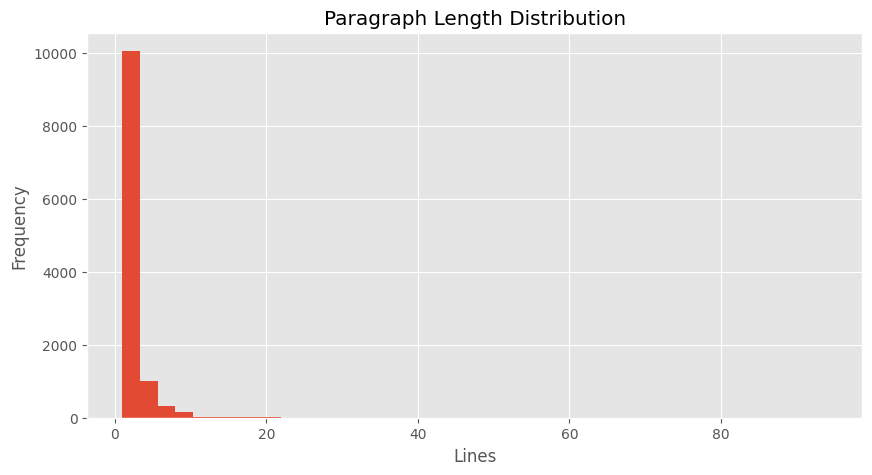

In [40]:
plt.figure(figsize=(10,5))
plt.hist(paragraphs, bins=40)
plt.title("Paragraph Length Distribution")
plt.xlabel("Lines")
plt.ylabel("Frequency")
plt.show()

In [41]:
import re
def classify_line(line):
    stripped = line.strip()
    if stripped == "":
        return "Whitespace"
    elif re.match(r"^=+.*=+$", stripped):
        return "Heading"
    elif stripped.isdigit():
        return "Numeric"
    else:
        return "Content"

In [42]:
line_types = [classify_line(line) for line in train_data]
pd.Series(line_types).value_counts()

,count
Content,17548
Whitespace,12951
Heading,6211
Numeric,8


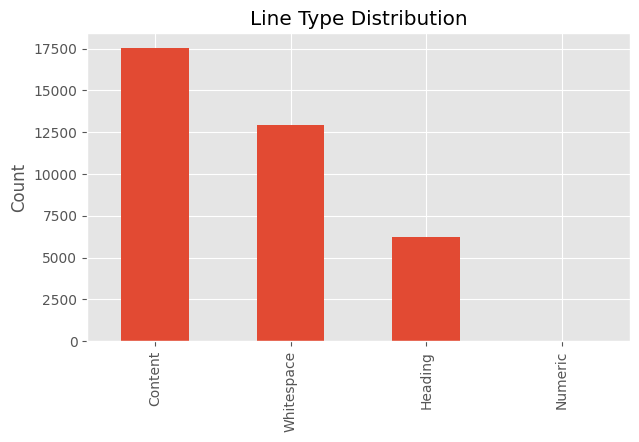

In [43]:
pd.Series(line_types).value_counts().plot.bar(figsize=(7,4))
plt.title("Line Type Distribution")
plt.ylabel("Count")
plt.show()

# PART 3 (VOCABULARY ANALYSIS)

In [48]:
from collections import Counter
tokens = []
for line in train_data:
    if line.strip():
        tokens.extend(line.split())
word_counter = Counter(tokens)

print(f"Total Tokens      : {len(tokens):,}")
print(f"Unique Tokens     : {len(word_counter):,}")

Total Tokens      : 2,051,910
Unique Tokens     : 76,616


In [49]:
word_lengths = [len(word) for word in word_counter.keys()]
vocab_stats = {
    "Total Tokens": len(tokens),
    "Unique Tokens": len(word_counter),
    "Type-Token Ratio": len(word_counter) / len(tokens),
    "Average Word Length": np.mean(word_lengths),
    "Median Word Length": np.median(word_lengths),
    "Longest Token": max(word_counter.keys(), key=len),
    "Longest Token Length": max(word_lengths),
    "Shortest Token Length": min(word_lengths),
}

pd.DataFrame(vocab_stats.items(), columns=["Metric", "Value"])

,Metric,Value
0,Total Tokens,2051910
1,Unique Tokens,76616
2,Type-Token Ratio,0.037339
3,Average Word Length,7.345346
4,Median Word Length,7.0
5,Longest Token,wikidocumentary.wikia.com.
6,Longest Token Length,26
7,Shortest Token Length,1


In [50]:
top_words = pd.DataFrame(
    word_counter.most_common(50),
    columns=["Word", "Frequency"]
)
top_words

,Word,Frequency
0,the,113161
1,",",99913
2,.,73388
3,of,56889
4,and,50603
5,in,39453
6,to,39190
7,a,34237
8,=,29570
9,"""",28309


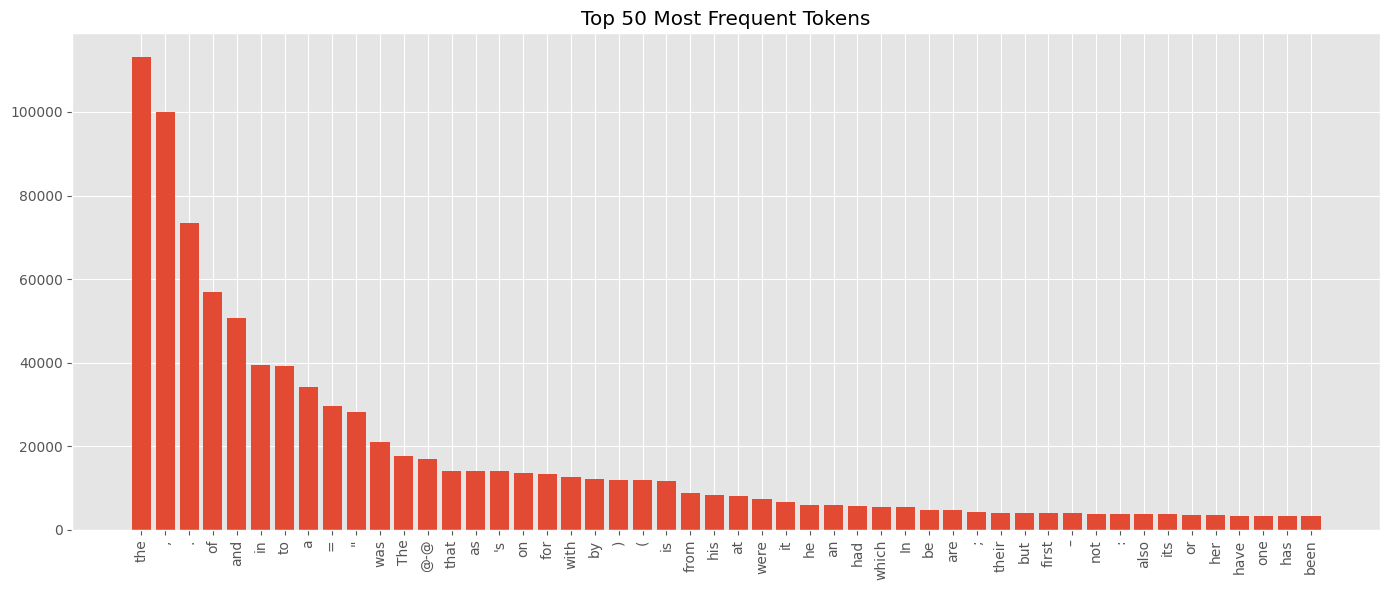

In [51]:
plt.figure(figsize=(14,6))
plt.bar(top_words["Word"], top_words["Frequency"])
plt.xticks(rotation=90)
plt.title("Top 50 Most Frequent Tokens")
plt.tight_layout()
plt.show()

In [52]:
least_words = [
    (word, freq)
    for word, freq in word_counter.items()
    if freq == 1
]
print(f"Singleton Words : {len(least_words):,}")
pd.DataFrame(
    least_words[:50],
    columns=["Word", "Frequency"]
)

Singleton Words : 32,055


,Word,Frequency
0,Unrecorded,1
1,Calamaty,1
2,forgiving,1
3,unvoiced,1
4,scanned,1
5,BliTZ,1
6,Abilities,1
7,boosts,1
8,depleting,1
9,Reila,1


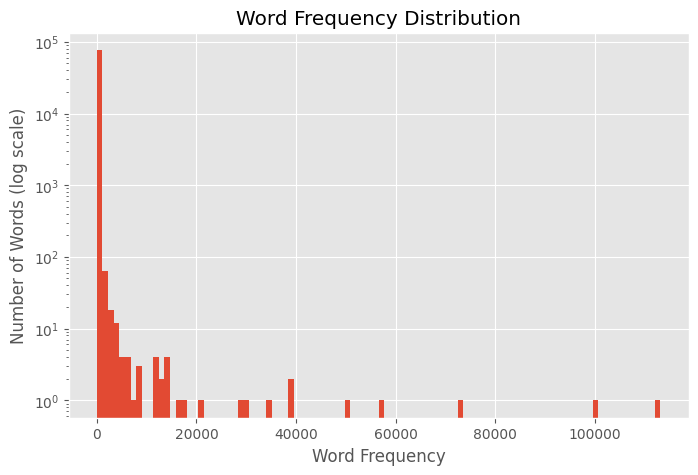

In [53]:
frequencies = list(word_counter.values())
plt.figure(figsize=(8,5))
plt.hist(
    frequencies,
    bins=100,
    log=True
)
plt.xlabel("Word Frequency")
plt.ylabel("Number of Words (log scale)")
plt.title("Word Frequency Distribution")
plt.show()

In [54]:
thresholds = [1, 2, 3, 5, 10, 20]
rows = []
total_vocab = len(word_counter)
total_tokens = len(tokens)
for threshold in thresholds:
    kept_words = {
        word: freq
        for word, freq in word_counter.items()
        if freq >= threshold
    }
    kept_vocab = len(kept_words)
    kept_tokens = sum(kept_words.values())
    rows.append({
        "Min Frequency": threshold,
        "Vocabulary Retained": kept_vocab,
        "Vocabulary %": kept_vocab / total_vocab * 100,
        "Token Coverage %": kept_tokens / total_tokens * 100
    })
coverage_df = pd.DataFrame(rows)
coverage_df

,Min Frequency,Vocabulary Retained,Vocabulary %,Token Coverage %
0,1,76616,100.000000,100.000000
1,2,44561,58.161481,98.437797
2,3,33276,43.432181,97.337846
3,5,23378,30.513209,95.702297
4,10,14445,18.853764,92.847834
5,20,8833,11.528923,89.140606


In [61]:
coverage_df["Tokens Replaced by <UNK> (%)"] = 100 - coverage_df["Token Coverage %"]
coverage_df["Vocabulary Removed (%)"] = 100 - coverage_df["Vocabulary %"]
coverage_df

,Min Frequency,Vocabulary Retained,Vocabulary %,Token Coverage %,Tokens Replaced by <UNK> (%),Vocabulary Removed (%)
0,1,76616,100.000000,100.000000,0.000000,0.000000
1,2,44561,58.161481,98.437797,1.562203,41.838519
2,3,33276,43.432181,97.337846,2.662154,56.567819
3,5,23378,30.513209,95.702297,4.297703,69.486791
4,10,14445,18.853764,92.847834,7.152166,81.146236
5,20,8833,11.528923,89.140606,10.859394,88.471077


In [55]:
groups = {
    "Frequency = 1": 0,
    "Frequency = 2": 0,
    "Frequency = 3": 0,
    "Frequency <= 5": 0,
    "Frequency <= 10": 0,
    "Frequency > 10": 0,
}

for freq in word_counter.values():

    if freq == 1:
        groups["Frequency = 1"] += 1

    if freq == 2:
        groups["Frequency = 2"] += 1

    if freq == 3:
        groups["Frequency = 3"] += 1

    if freq <= 5:
        groups["Frequency <= 5"] += 1

    if freq <= 10:
        groups["Frequency <= 10"] += 1

    if freq > 10:
        groups["Frequency > 10"] += 1

pd.DataFrame(groups.items(), columns=["Group", "Count"])

,Group,Count
0,Frequency = 1,32055
1,Frequency = 2,11285
2,Frequency = 3,6032
3,Frequency <= 5,55990
4,Frequency <= 10,63095
5,Frequency > 10,13521


In [56]:
running_vocab = set()
growth = []

for token in tokens:
    running_vocab.add(token)
    growth.append(len(running_vocab))

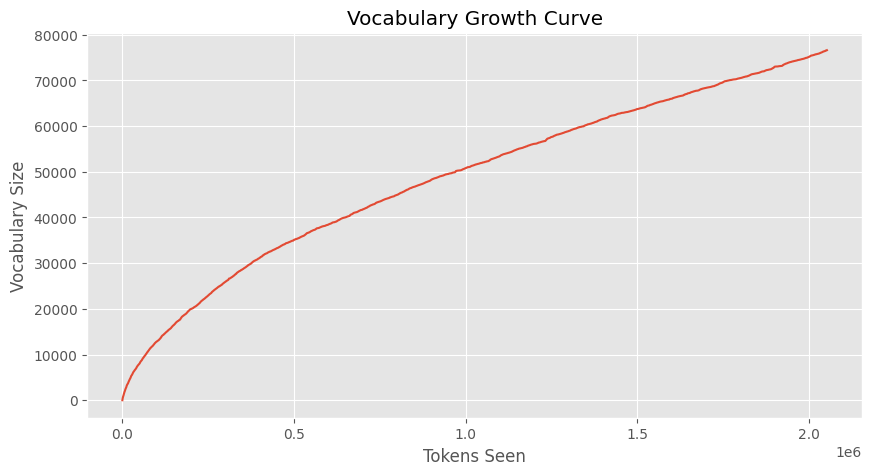

In [57]:
plt.figure(figsize=(10,5))

plt.plot(growth)

plt.xlabel("Tokens Seen")

plt.ylabel("Vocabulary Size")

plt.title("Vocabulary Growth Curve")

plt.show()

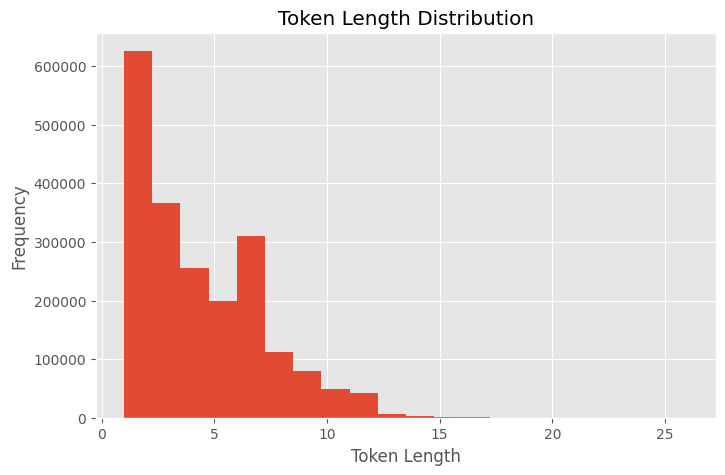

In [59]:
token_lengths = [len(word) for word in tokens]
plt.figure(figsize=(8,5))
plt.hist(token_lengths, bins=20)
plt.xlabel("Token Length")
plt.ylabel("Frequency")
plt.title("Token Length Distribution")
plt.show()

In [60]:
import re
special_tokens = sorted({
    token
    for token in word_counter
    if re.search(r"[^A-Za-z0-9]", token)
})
print(f"Special Tokens: {len(special_tokens):,}")
special_tokens[:100]

Special Tokens: 3,120


['!',
 '"',
 '#',
 '$',
 '%',
 '&',
 "'",
 "'Académie",
 "'Action",
 "'Addario",
 "'Africaine",
 "'Albert",
 "'Alesandro",
 "'Alkan",
 "'Andrade",
 "'Anjou",
 "'Apollon",
 "'Aquin",
 "'Aragona",
 "'Art",
 "'Artus",
 "'Assomption",
 "'Aubeterre",
 "'Aubigny",
 "'Aude",
 "'Auteroche",
 "'Automobile",
 "'Avria",
 "'Brien",
 "'Callaghan",
 "'Carmel",
 "'Casey",
 "'Clock",
 "'Connell",
 "'Connor",
 "'Cruz",
 "'Daniel",
 "'Day",
 "'Dell",
 "'Donnell",
 "'Eglise",
 "'Elanna",
 "'Entrée",
 "'Esope",
 "'Europe",
 "'Evercy",
 "'Extrême",
 "'Hara",
 "'Hare",
 "'Harmattan",
 "'Hatuvu",
 "'Herlihy",
 "'Histoire",
 "'Hommedieu",
 "'Hondt",
 "'Hérault",
 "'Hérode",
 "'Indy",
 "'Italia",
 "'Ivoire",
 "'K'in",
 "'Keefe",
 "'Keeffe",
 "'Las",
 "'Leary",
 "'Les",
 "'Malley",
 "'Mara",
 "'Neal",
 "'Neil",
 "'Neill",
 "'Nique",
 "'Oc",
 "'Officiel",
 "'Opéra",
 "'Or",
 "'Orléans",
 "'Ospital",
 "'Ouverture",
 "'Pau",
 "'Pol",
 "'Py",
 "'Quinn",
 "'Rouke",
 "'Rourke",
 "'Ryan",
 "'Shara",
 "'Shea",
 "'Shone

In [62]:
word_lengths = [
    len(line.split())
    for line in train_data
    if line.strip()
]
stats = pd.Series(word_lengths).describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)
stats

,0
count,23767.000000
mean,86.334413
std,81.632409
min,1.000000
50%,74.000000
75%,139.000000
90%,200.000000
95%,237.000000
99%,319.000000
max,699.000000


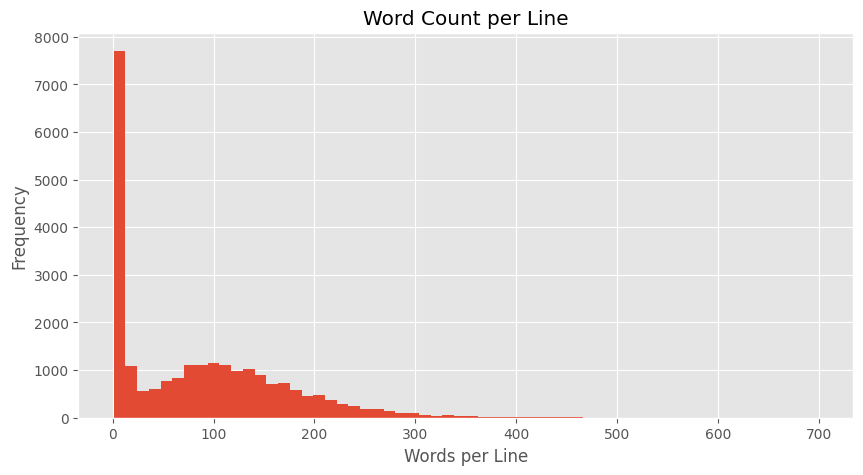

In [63]:
plt.figure(figsize=(10,5))
plt.hist(word_lengths, bins=60)
plt.xlabel("Words per Line")
plt.ylabel("Frequency")
plt.title("Word Count per Line")
plt.show()

In [71]:
candidate_lengths = [5,10,15,20,25,30,40,50,70,100,150,180,200,220,250,270,300,400, 450, 500, 550]
rows = []
total_lines = len(word_lengths)
for length in candidate_lengths:
    covered = sum(w <= length for w in word_lengths)
    rows.append({
        "Sequence Length": length,
        "Lines Covered": covered,
        "Coverage %": covered/total_lines*100
    })
coverage = pd.DataFrame(rows)
coverage

,Sequence Length,Lines Covered,Coverage %
0,5,2543,10.699710
1,10,7207,30.323558
2,15,8125,34.186056
3,20,8504,35.780704
4,25,8832,37.160769
5,30,9098,38.279968
6,40,9580,40.307990
7,50,10116,42.563218
8,70,11549,48.592586
9,100,14409,60.626078


In [72]:
token_lengths = [len(token) for token in tokens]
pd.Series(token_lengths).describe()

,0
count,2.051910e+06
mean,4.285518e+00
std,2.752215e+00
min,1.000000e+00
25%,2.000000e+00
50%,4.000000e+00
75%,6.000000e+00
max,2.600000e+01


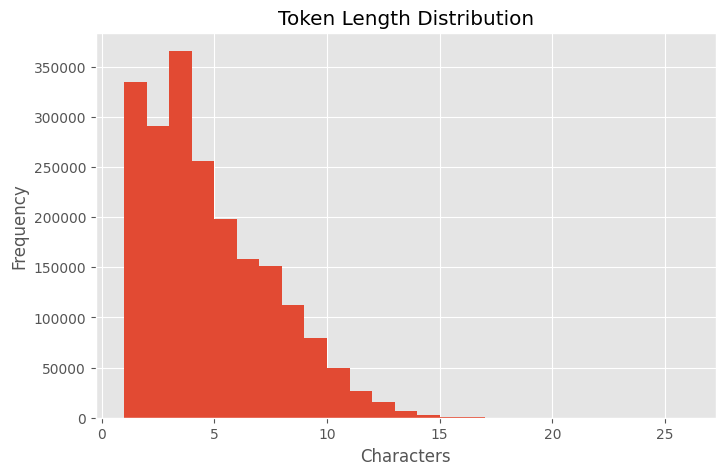

In [73]:
plt.figure(figsize=(8,5))
plt.hist(token_lengths,bins=25)
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.title("Token Length Distribution")
plt.show()

In [74]:
lower = 0
upper = 0
title = 0
mixed = 0

for token in word_counter:

    if token.islower():
        lower += 1

    elif token.isupper():
        upper += 1

    elif token.istitle():
        title += 1

    else:
        mixed += 1

pd.DataFrame({
    "Category":[
        "Lower",
        "Upper",
        "Title",
        "Mixed"
    ],
    "Count":[
        lower,
        upper,
        title,
        mixed
    ]
})

,Category,Count
0,Lower,36633
1,Upper,2181
2,Title,34464
3,Mixed,3338


In [75]:
import re
number_tokens = [
    token
    for token in word_counter
    if re.search(r"\d",token)
]
print("Number Tokens:",len(number_tokens))

number_tokens[:100]

Number Tokens: 3255


['3',
 '戦場のヴァルキュリア3',
 '2011',
 '2010',
 '2014',
 '4',
 '422',
 'No.7',
 'No.1',
 'No.13',
 '422nd',
 '27',
 '23',
 '2012',
 '102',
 '779',
 '152',
 '500',
 '4Gamer.net',
 '3DS',
 '戦場のヴァルキュリア３',
 '29',
 '31',
 '1',
 '1840',
 '1942',
 '1997',
 '2001',
 '1894',
 '10',
 '14',
 '000',
 '30',
 '0',
 '91',
 '1860',
 '15',
 '1861',
 '18',
 '28',
 '5',
 '6',
 '4th',
 '8',
 '247',
 '250',
 '520',
 'M1822',
 '.69',
 '625',
 '53',
 'M1842',
 '357',
 'M1855',
 '.58',
 '900',
 'M1817',
 '125',
 'M1841',
 '54',
 'M1847',
 '2',
 '267',
 '864',
 '9600',
 '364',
 '5th',
 '6th',
 '7th',
 '8th',
 'M1816',
 '9th',
 '10th',
 '3rd',
 '1st',
 '2nd',
 '11th',
 '12th',
 '1862',
 '1863',
 '75',
 '1500',
 '149',
 '20',
 '26',
 '750',
 '275',
 '117',
 '130',
 '96',
 '236',
 '752',
 '11',
 '1864',
 '1874',
 '1873',
 '1868',
 '1880',
 '1880s',
 '1890']

In [76]:
unicode_tokens = [
    token
    for token in word_counter
    if any(ord(ch)>127 for ch in token)
]
print(len(unicode_tokens))

unicode_tokens[:100]

2156


['Senjō',
 '戦場のヴァルキュリア3',
 'もしも君が願うのなら',
 'Jūsō',
 '戦場のヴァルキュリア３',
 '誰がための銃瘡',
 'Kondō',
 'Ōnogi',
 '灯',
 'いつか咲く光の花',
 '名もなき誓いの花',
 '-赤き運命の戦乙女-',
 'Æsthetic',
 '�',
 '²',
 '–',
 '’',
 '£',
 '—',
 '₤',
 'Réseau',
 '†',
 '‡',
 '°',
 '₹',
 '“',
 '”',
 'István',
 'Škoda',
 'nṯr',
 'nṯrt',
 'nṯrw',
 'rmṯ',
 'Jéquier',
 'ḏsr',
 '‘',
 'JÄGERMUSIC',
 'Jägermeister',
 'Zrínyi',
 'Korvettenkapitän',
 'Polić',
 'Grélet',
 'µm',
 'Vrålstad',
 'β',
 'Juárez',
 'Díaz',
 'Ramón',
 'León',
 'José',
 'María',
 'Suárez',
 'Vázquez',
 'Gómez',
 'Potosí',
 'Ahí',
 'mándame',
 'más',
 'González',
 'Michoacán',
 'Izúcar',
 'Estañol',
 "'état",
 'Alí',
 'Leónidas',
 'Ñico',
 'Joaquín',
 'García',
 'Agustín',
 'Rómulo',
 'Román',
 'Sadhalá',
 'Español',
 'chargé',
 'feɪ',
 'née',
 '86.02º',
 'Nāgas',
 'Brüster',
 'Ché',
 'Ågren',
 'Zagrebačka',
 'Leopoldstädter',
 'Praška',
 'Jelačić',
 'Förster',
 'Ustaša',
 'Zafranović',
 'Grivičić',
 'Pavelić',
 'Grüner',
 'Silađin',
 'Tuđman',
 'Jérôme',
 'Impétueux',
 'Ku

In [77]:
from collections import Counter
character_counter = Counter()
for token in tokens:
    character_counter.update(token)
character_df = pd.DataFrame(
    character_counter.most_common(50),
    columns=["Character","Frequency"]
)

character_df

,Character,Frequency
0,e,990626
1,t,690297
2,a,685507
3,n,593094
4,i,588695
5,o,585162
6,r,533179
7,s,514154
8,h,387532
9,l,328199


In [78]:
import string
punct_counter = Counter()
for token in tokens:
    for ch in token:
        if ch in string.punctuation:
            punct_counter[ch]+=1
pd.DataFrame(
    punct_counter.most_common(),
    columns=["Punctuation","Frequency"]
)

,Punctuation,Frequency
0,",",102624
1,.,84291
2,@,45600
3,=,29570
4,"""",28309
5,',18655
6,-,17337
7,),12004
8,(,11992
9,;,4224


In [79]:
thresholds=[2,3,5,10]
rows=[]
for t in thresholds:
    unk=sum(
        freq
        for freq in word_counter.values()
        if freq<t
    )
    rows.append({
        "Min Frequency":t,
        "UNK Tokens":unk,
        "UNK %":unk/len(tokens)*100
    })

pd.DataFrame(rows)

,Min Frequency,UNK Tokens,UNK %
0,2,32055,1.562203
1,3,54625,2.662154
2,5,88185,4.297703
3,10,146756,7.152166
